<style>
.jp-RenderedHTMLCommon,
.text_cell_render {
  font-family: medium-content-serif-font, Georgia, Cambria, "Times New Roman", Times, serif;
  font-size: 17px;
  line-height: 1.65;
  color: #1f2328;
}
.jp-RenderedHTMLCommon h1,
.jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3,
.text_cell_render h1,
.text_cell_render h2,
.text_cell_render h3 {
  font-family: sohne, "Helvetica Neue", Helvetica, Arial, sans-serif;
  color: #111;
}
.jp-RenderedHTMLCommon h1,
.text_cell_render h1 {
  font-size: 2.6rem;
  letter-spacing: -0.03em;
}
.jp-RenderedHTMLCommon h2,
.text_cell_render h2 {
  margin-top: 1.8em;
}
</style>

# Expediente D. Contrato que crece

Data Analytics | Semanas 7–8 | 2026-2

Este notebook acompaña la lectura ¿Qué puede decir realmente un contrato público?

Afirmación que se investigará:

Algunas características observables de los contratos están asociadas con la presencia posterior de registros de adición.

Este expediente utiliza dos archivos: `data/secop_recorte.csv` y `data/secop_adiciones.csv`.

Durante la primera semana se construyen tres evidencias y se documentan tres decisiones de preparación. En la segunda semana se incorpora una objeción y se revisa si la conclusión inicial se mantiene.

El objetivo es que cada cifra utilizada en la conclusión pueda localizarse en el notebook y que el alcance de la afirmación corresponda a lo que realmente muestran los datos.


## Preparar los datos

Ubique el notebook junto a la carpeta `data`.

```text
Expediente_D.ipynb
data/
├── secop_recorte.csv
└── secop_adiciones.csv
```

`secop_recorte.csv` contiene los contratos asignados al equipo. `secop_adiciones.csv` contiene los registros de adición asociados con esos contratos.

No es necesario descargar datos, seleccionar un equipo ni modificar filtros.


In [3]:
from pathlib import Path
from statistics import NormalDist
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CONTRACTS_FILE = Path("data") / "secop_recorte.csv"
ADDITIONS_FILE = Path("data") / "secop_adiciones.csv"

if not CONTRACTS_FILE.exists():
    raise FileNotFoundError("No se encontró data/secop_recorte.csv.")

if not ADDITIONS_FILE.exists():
    raise FileNotFoundError("No se encontró data/secop_adiciones.csv.")

df_raw = pd.read_csv(CONTRACTS_FILE, dtype=str)
adiciones_raw = pd.read_csv(ADDITIONS_FILE, dtype=str)

print("Contratos:", f"{len(df_raw):,}")
print("Registros de adición:", f"{len(adiciones_raw):,}")


Contratos: 50,000
Registros de adición: 50,000


## Comprender el archivo antes de analizarlo

Cada fila de `secop_recorte.csv` representa un contrato incluido en el conjunto asignado al equipo. El archivo no corresponde a todo SECOP II, sino a una parte previamente seleccionada para la actividad.

La columna `ciudad`, cuando está disponible, identifica la ciudad de registro de la entidad que publica el contrato. No debe interpretarse automáticamente como el lugar físico donde se ejecutó el servicio, la obra o el suministro.

Las siguientes conversiones permiten trabajar con valores y fechas sin eliminar registros.


In [4]:
df = df_raw.copy()

for column in ["valor_del_contrato", "dias_adicionados"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

for column in [
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
]:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")

if {
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
}.issubset(df.columns):
    df["duracion_dias"] = (
        df["fecha_de_fin_del_contrato"]
        - df["fecha_de_inicio_del_contrato"]
    ).dt.days

if {"valor_del_contrato", "duracion_dias"}.issubset(df.columns):
    months = df["duracion_dias"] / 30.44
    df["valor_mensual_equivalente"] = (
        df["valor_del_contrato"] / months.where(months > 0)
    )

sample_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "tipo_de_contrato",
        "modalidad_de_contratacion",
        "valor_del_contrato",
        "fecha_de_firma",
    ]
    if c in df.columns
]

df[sample_columns].head()


,id_contrato,nombre_entidad,ciudad,proveedor_adjudicado,tipo_de_contrato,modalidad_de_contratacion,valor_del_contrato,fecha_de_firma
0,CO1.PCCNTR.6729995,AGENCIA DISTRITAL DE INFRAESTRUCTURA DEL DISTR...,Barranquilla,HANSEL MOISES ANIBAL BOLAÑO,Prestación de servicios,Contratación directa,2640000.0,2024-09-09
1,CO1.PCCNTR.6270130,ALCALDIA DE PUERTO COLOMBIA,Puerto Colombia,BETSY GONZALEZ LUNA,Prestación de servicios,Contratación directa,5700000.0,2024-04-30
2,CO1.PCCNTR.6495300,AGENCIA DISTRITAL DE INFRAESTRUCTURA DEL DISTR...,Barranquilla,DEIVIS MANUEL CAMACHO CUELLO,Prestación de servicios,Contratación directa,3760000.0,2024-07-05
3,CO1.PCCNTR.7940108,INSTITUCION UNIVERSITARIA DE BARRANQUILLA-IUB,Barranquilla,Stiven Alfonso Santiago Pua,Prestación de servicios,Contratación directa,10500084.0,2025-06-12
4,CO1.PCCNTR.6936113,DEPARTAMENTO DEL ATLANTICO**,Barranquilla,FRANK CASTRO,Prestación de servicios,Contratación directa,7500000.0,2024-10-25


### Antes de seguir

1. ¿Qué representa una fila?
R/T Cada una de las filas muestra un registro de contrato en la base de datos de SECOP, Cada una incluye, informacion del contrato, como la entidad contratante, el proveedor, el tipo y modalidad de contratacion, el valor y la fecha de la firma.

2. ¿Qué información permite identificar a la entidad y al proveedor?
R/T La entidad se puede identificar principalmente mediante la columna nombre_entidad, que muestra el nombre de la institución que realiza la contratación. El proveedor se identifica mediante proveedor_adjudicado, que contiene el nombre de la persona o empresa a la que fue adjudicado el contrato.

     Además, id_contrato permite identificar de manera individual cada contrato.

3. ¿Qué variable monetaria aparece en el archivo?
R/T La principal variable monetaria es valor_del_contrato, que representa el valor económico asignado al contrato.

4. ¿Qué variable o columna necesita comprender mejor antes de utilizarla?
R/T Una variable que necesita comprenderse mejor es duracion_del_contrato, porque su interpretación y calidad deben verificarse antes de utilizarla en el análisis. En el código se calcula una nueva variable llamada duracion_dias a partir de las fechas de inicio y finalización del contrato.


## Primera semana: describir el conjunto asignado

La primera revisión se concentra en `valor_del_contrato`. Se estudiará una variable por separado antes de introducir comparaciones entre grupos.

La media, la mediana y los percentiles no responden exactamente la misma pregunta. Si la distribución contiene unos pocos contratos de valor muy alto, la media puede alejarse considerablemente de la mediana.


In [ ]:
if "valor_del_contrato" not in df.columns:
    raise KeyError("El archivo no contiene la columna valor_del_contrato.")

contract_value = df["valor_del_contrato"].dropna()

value_summary = pd.Series({
    "contratos con valor registrado": len(contract_value),
    "media": contract_value.mean(),
    "mediana": contract_value.median(),
    "percentil 25": contract_value.quantile(0.25),
    "percentil 75": contract_value.quantile(0.75),
    "percentil 90": contract_value.quantile(0.90),
    "mínimo": contract_value.min(),
    "máximo": contract_value.max(),
    "contratos con valor 0": int((contract_value == 0).sum()),
})

value_summary.to_frame("resultado")


,resultado
contratos con valor registrado,5.000000e+04
media,1.664533e+08
mediana,1.750000e+07
percentil 25,8.183000e+06
percentil 75,3.630000e+07
percentil 90,6.600000e+07
mínimo,0.000000e+00
máximo,1.729697e+11
contratos con valor 0,1.750000e+02


In [8]:
if "valor_del_contrato" not in df.columns:
    raise KeyError("El archivo no contiene la columna valor_del_contrato.")

contract_value = df["valor_del_contrato"].dropna()

value_summary = {
    "Contratos con valor registrado": len(contract_value),
    "Media": contract_value.mean(),
    "Mediana": contract_value.median(),
    "Percentil 25": contract_value.quantile(0.25),
    "Percentil 75": contract_value.quantile(0.75),
    "Percentil 90": contract_value.quantile(0.90),
    "Mínimo": contract_value.min(),
    "Máximo": contract_value.max(),
    "Contratos con valor 0": int((contract_value == 0).sum()),
}

for nombre, valor in value_summary.items():
    if isinstance(valor, (int, float)):
        print(f"{nombre}: {valor:,.0f}".replace(",", "."))
    else:
        print(f"{nombre}: {valor}")

Contratos con valor registrado: 50.000
Media: 166.453.282
Mediana: 17.500.000
Percentil 25: 8.183.000
Percentil 75: 36.300.000
Percentil 90: 66.000.000
Mínimo: 0
Máximo: 172.969.667.789
Contratos con valor 0: 175


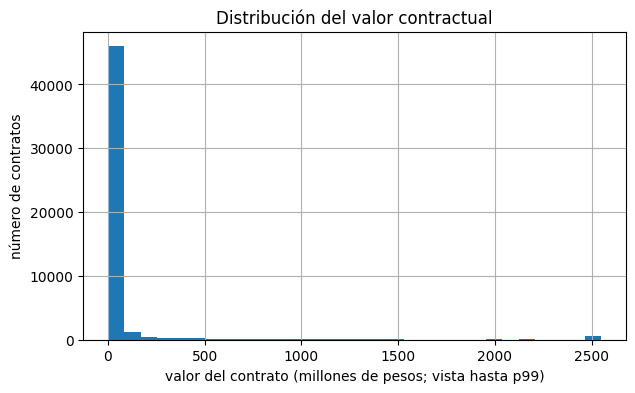

In [6]:
upper_view = contract_value.quantile(0.99)

plt.figure(figsize=(7, 4))
(contract_value.clip(upper=upper_view) / 1_000_000).hist(bins=30)
plt.xlabel("valor del contrato (millones de pesos; vista hasta p99)")
plt.ylabel("número de contratos")
plt.title("Distribución del valor contractual")
plt.show()


### Deténgase y revise

1. ¿La media y la mediana son semejantes o muy diferentes?
R/T La media y la mediana son muy diferentes: la media es aproximadamente $166,45 millones, mientras que la mediana es $17,5 millones. Esta diferencia evidencia la presencia de contratos con valores muy altos que elevan la media.

2. ¿Cuál de las dos describe mejor un contrato típico dentro de estos datos?
R/T La mediana describe mejor un contrato típico, ya que es menos sensible a los valores extremos. En este caso, el 50 % de los contratos tiene un valor igual o inferior a $17,5 millones.

3. ¿Qué muestra el histograma sobre la forma de la distribución?
R/T El histograma muestra una distribución asimétrica hacia la derecha, con una concentración de contratos en valores relativamente bajos y una cola hacia valores muy altos.

4. ¿Por qué limitar la escala visual al percentil 99 no equivale a eliminar esos contratos del análisis?
R/T Limitar la escala al percentil 99 solo afecta la visualización del histograma. Los contratos con valores superiores al percentil 99 no se eliminan de los datos ni de los cálculos estadísticos; simplemente se representan hasta ese límite para facilitar la interpretación visual.


## Revisar la calidad antes de preparar los datos

Un faltante, un valor en cero, una repetición o un valor extremo no se elimina automáticamente. Primero debe establecerse si afecta la pregunta que se quiere responder.

La siguiente revisión muestra aspectos que pueden modificar las conclusiones.


In [9]:
quality_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "documento_proveedor",
        "valor_del_contrato",
        "fecha_de_inicio_del_contrato",
        "fecha_de_fin_del_contrato",
        "duracion_dias",
    ]
    if c in df.columns
]

quality = pd.DataFrame({
    "faltantes": df[quality_columns].isna().sum(),
    "porcentaje_faltante": (df[quality_columns].isna().mean() * 100).round(1),
    "valores_unicos": df[quality_columns].nunique(dropna=True),
})

display(quality)

if "id_contrato" in df.columns:
    print(
        "IDs de contrato repetidos:",
        int(df["id_contrato"].duplicated(keep=False).sum())
    )

q1, q3 = df["valor_del_contrato"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr

print("Contratos con valor 0:", int((df["valor_del_contrato"] == 0).sum()))
print(
    "Posibles valores extremos según 1.5 × IQR:",
    int((df["valor_del_contrato"] > upper_iqr).sum())
)

if "duracion_dias" in df.columns:
    invalid_duration = (
        df["duracion_dias"].isna()
        | (df["duracion_dias"] <= 0)
    ).sum()
    print("Duraciones faltantes o no positivas:", int(invalid_duration))


,faltantes,porcentaje_faltante,valores_unicos
id_contrato,0,0.0,50000
nombre_entidad,0,0.0,88
ciudad,0,0.0,19
proveedor_adjudicado,0,0.0,25408
documento_proveedor,0,0.0,25408
valor_del_contrato,0,0.0,11271
fecha_de_inicio_del_contrato,497,1.0,671
fecha_de_fin_del_contrato,0,0.0,911
duracion_dias,497,1.0,640


IDs de contrato repetidos: 0
Contratos con valor 0: 175
Posibles valores extremos según 1.5 × IQR: 4274
Duraciones faltantes o no positivas: 599


### Comprobar si una decisión cambia el resultado

Antes de decidir qué hacer con los valores en cero o con los contratos más altos, conviene observar cuánto cambia una estadística sencilla.

La siguiente comparación no prescribe una limpieza. Su función es mostrar si la mediana resulta sensible a tres formas distintas de preparar el valor contractual.


In [10]:
medians = {}

all_values = df["valor_del_contrato"].dropna()
if len(all_values):
    medians["sin retirar ceros"] = all_values.median()

positive_values = df.loc[
    df["valor_del_contrato"] > 0,
    "valor_del_contrato"
].dropna()

if len(positive_values):
    medians["solo valores positivos"] = positive_values.median()

if len(positive_values):
    p99 = positive_values.quantile(0.99)
    below_p99 = positive_values[positive_values <= p99]
    medians["positivos, sin el 1 % superior"] = below_p99.median()

pd.Series(medians, name="mediana_valor")


sin retirar ceros                 17500000.0
solo valores positivos            17500000.0
positivos, sin el 1 % superior    17400000.0
Name: mediana_valor, dtype: float64

### Tres decisiones de preparación

Documente tres decisiones que realmente se desprendan de sus datos. Para cada una, responda:

1. Valores del contrato iguales a cero

¿Qué situación encontré?
Se encontraron 175 contratos con un valor contractual igual a $0, de un total de 50.000 contratos con valor registrado. Esto representa aproximadamente el 0,35 % de los contratos.

¿Qué tratamiento decidí aplicar?
Decidimos no eliminar automáticamente estos registros. Primero se comparan las medianas utilizando todos los valores, únicamente los valores positivos y los valores positivos sin el 1 % superior, para determinar si los ceros afectan de manera importante el resultado.

¿Qué salida del notebook respalda la decisión?
La revisión de calidad identificó 175 contratos con valor igual a cero. Además, la comparación de medianas permite verificar si incluir estos registros modifica de manera importante el valor típico del contrato.

¿Qué podría cambiar en la conclusión si la decisión fuera equivocada?
Si los valores de $0 fueran errores de registro, incluirlos podría disminuir artificialmente el valor típico de los contratos. Si fueran valores válidos, eliminarlos podría provocar una pérdida de información.

2. Valores contractuales extremos

¿Qué situación encontré?
Se identificaron posibles valores extremos en la variable valor_del_contrato. La mediana es de $17.500.000, mientras que el máximo alcanza aproximadamente $172.969.700.000. También se observa una diferencia importante entre la media, de aproximadamente $166.453.300, y la mediana.

¿Qué tratamiento decidí aplicar?
Decidimos conservar los valores extremos en los datos y no eliminarlos automáticamente. Para facilitar la interpretación gráfica, se puede limitar la visualización al percentil 99, sin eliminar los registros originales.

¿Qué salida del notebook respalda la decisión?
La tabla descriptiva muestra la diferencia entre la media, la mediana y el máximo, y el análisis mediante 1,5 × IQR permite identificar la cantidad de posibles valores extremos.

¿Qué podría cambiar en la conclusión si la decisión fuera equivocada?
Si los valores extremos fueran errores y se conservaran, podrían aumentar artificialmente la media y afectar análisis basados en promedios. Si fueran contratos reales y se eliminaran, se perdería información importante sobre los contratos de mayor valor.

3. Duraciones faltantes o no válidas

¿Qué situación encontré?
La variable duracion_dias se calcula utilizando la fecha de inicio y la fecha de finalización del contrato. La revisión permite identificar contratos con duración faltante o con una duración menor o igual a cero, los cuales requieren revisión antes de utilizarse en análisis posteriores.

¿Qué tratamiento decidí aplicar?
Decidimos no utilizar automáticamente las duraciones faltantes o no positivas en comparaciones posteriores. Primero se deben revisar las fechas de inicio y finalización que originan la duración.

¿Qué salida del notebook respalda la decisión?
La salida denominada “Duraciones faltantes o no positivas” muestra la cantidad de registros que presentan este problema.

¿Qué podría cambiar en la conclusión si la decisión fuera equivocada?
Si se utilizaran duraciones incorrectas, podrían encontrarse relaciones engañosas entre la duración y otras variables, como el valor del contrato. Por otro lado, eliminar registros válidos podría reducir innecesariamente la información disponible para el análisis.
No es necesario que todos los equipos adopten las mismas decisiones.


## Relacionar contratos y adiciones

Los dos archivos se relacionan mediante `id_contrato`. En `secop_recorte.csv`, cada fila corresponde a un contrato. En `secop_adiciones.csv`, un mismo contrato puede aparecer más de una vez porque puede tener varios registros de adición.

Por esta razón, primero se cuentan los registros de adición por contrato y después se incorpora ese resultado al archivo principal.


In [13]:
if "id_contrato" not in df.columns:
    raise KeyError("secop_recorte.csv no contiene id_contrato.")

if "id_contrato" not in adiciones_raw.columns:
    raise KeyError("secop_adiciones.csv no contiene id_contrato.")

adiciones = adiciones_raw.copy()

if "fecharegistro" in adiciones.columns:
    adiciones["fecharegistro"] = pd.to_datetime(
        adiciones["fecharegistro"],
        errors="coerce"
    )

if "identificador" in adiciones.columns:
    additions_by_contract = (
        adiciones.groupby("id_contrato")
                 .agg(
                     numero_adiciones=("identificador", "nunique"),
                     ultima_adicion=("fecharegistro", "max")
                     if "fecharegistro" in adiciones.columns
                     else ("identificador", "size"),
                 )
                 .reset_index()
    )
else:
    additions_by_contract = (
        adiciones.groupby("id_contrato")
                 .size()
                 .rename("numero_adiciones")
                 .reset_index()
    )

df = df.merge(
    additions_by_contract,
    on="id_contrato",
    how="left"
)

df["numero_adiciones"] = (
    pd.to_numeric(df["numero_adiciones"], errors="coerce")
      .fillna(0)
      .astype(int)
)

df["tuvo_adicion"] = df["numero_adiciones"] > 0

print(
    "Contratos con al menos un registro de adición:",
    int(df["tuvo_adicion"].sum())
)
print(
    "Porcentaje de contratos con al menos un registro de adición:",
    round(df["tuvo_adicion"].mean() * 100, 1),
    "%"
)

df[
    ["id_contrato", "valor_del_contrato", "numero_adiciones", "tuvo_adicion"]
].head()


Contratos con al menos un registro de adición: 70
Porcentaje de contratos con al menos un registro de adición: 0.1 %


,id_contrato,valor_del_contrato,numero_adiciones,tuvo_adicion
0,CO1.PCCNTR.6729995,2640000.0,0,False
1,CO1.PCCNTR.6270130,5700000.0,0,False
2,CO1.PCCNTR.6495300,3760000.0,0,False
3,CO1.PCCNTR.7940108,10500084.0,0,False
4,CO1.PCCNTR.6936113,7500000.0,0,False


### Deténgase y revise

1. ¿Por qué no se debe unir directamente una fila de contrato con una sola fila de adición?
R/T No se debe unir directamente una fila de contrato con una sola fila de adición porque un mismo contrato puede tener varios registros en secop_adiciones.csv. Una unión directa podría duplicar los contratos. Por eso primero se agrupan los registros por id_contrato y se cuentan sus registros asociados.

2. ¿Qué significa `numero_adiciones`?
R/T numero_adiciones representa la cantidad de registros asociados a cada contrato en la base de adiciones. Se obtiene agrupando por id_contrato y contando los identificadores únicos.

3. ¿Qué significa `tuvo_adicion`?
R/T tuvo_adicion indica si un contrato tiene al menos un registro asociado en la base de adiciones. True significa que tiene uno o más registros y False significa que no tiene ninguno. Esta variable no implica necesariamente que el registro corresponda a una adición de valor.

4. ¿Qué contratos quedan con cero registros de adición después de la unión?
R/T Los contratos que quedan con cero registros son aquellos cuyo id_contrato no aparece en secop_adiciones.csv. En este conjunto de datos, 49.930 de los 50.000 contratos no encontraron coincidencia en la segunda base.


## Expediente D: comparar contratos con y sin registros de adición

La siguiente comparación es descriptiva. Indica si los contratos con registros de adición presentan valores o duraciones diferentes dentro de este conjunto.

Una diferencia observada no demuestra que el valor o la duración hayan causado la adición.


In [14]:
comparison_columns = [
    c for c in ["valor_del_contrato", "duracion_dias"]
    if c in df.columns
]

summary_additions = (
    df.groupby("tuvo_adicion")[comparison_columns]
      .median()
      .rename(index={
          False: "sin registro de adición",
          True: "con registro de adición",
      })
)

display(summary_additions)

print(
    "Mediana del número de adiciones entre contratos con alguna adición:",
    df.loc[df["tuvo_adicion"], "numero_adiciones"].median()
)


,valor_del_contrato,duracion_dias
tuvo_adicion,,
sin registro de adición,17500000.0,120.0
con registro de adición,38009166.5,268.5


Mediana del número de adiciones entre contratos con alguna adición: 1.0


### Interpretar el resultado

1. ¿Qué proporción de los contratos tiene al menos un registro de adición?

De los 50.000 contratos analizados, 70 tienen al menos un registro asociado en la base de adiciones. Esto corresponde al 0,14 % de los contratos. El 99,86 % restante no presenta coincidencia con la base de adiciones.

2. ¿Cómo cambia el valor mediano entre contratos con y sin adición?

El valor mediano es de $17.500.000 para los contratos sin registro de adición y de $38.009.166,50 para los contratos con registro de adición. Esto representa una diferencia de $20.509.166,50. Por lo tanto, los contratos con registro presentan un valor mediano mayor. Sin embargo, esta diferencia es descriptiva y no demuestra que un mayor valor contractual cause la aparición de un registro de adición.

3. ¿Cómo cambia la duración mediana?

La duración mediana es de 120 días para los contratos sin registro de adición y de 268,5 días para los contratos con registro de adición. Esto representa una diferencia de 148,5 días. Por lo tanto, los contratos con registro presentan una duración mediana mayor dentro de este conjunto de datos. Esta diferencia tampoco permite establecer una relación causal.

4. ¿Qué explicación alternativa podría producir esas diferencias?

Las diferencias podrían estar relacionadas con otras características de los contratos, como la modalidad de contratación, el tipo de contrato o la entidad contratante. Estas variables podrían estar relacionadas tanto con el valor y la duración de los contratos como con la aparición de registros en la base de adiciones. Además, los grupos tienen tamaños muy diferentes: 70 contratos con registro frente a 49.930 sin registro, por lo que los resultados deben interpretarse con cautela. También es importante recordar que un registro en la base de adiciones no necesariamente corresponde a una adición de valor, ya que la base contiene diferentes tipos de modificaciones.

## Tablero de evidencia de la primera semana

Seleccione tres hallazgos. Para cada uno registre el hallazgo, la cifra o tabla que lo respalda, una interpretación posible y una duda pendiente.

La conclusión debe referirse a asociación y a registros de adición. No debe presentarse como una predicción del futuro ni como evidencia causal.


## Segunda semana: poner a prueba la conclusión

Objeción de trabajo: las diferencias observadas pueden deberse a que ciertos tipos de contrato o modalidades son, al mismo tiempo, más costosos y más propensos a recibir adiciones.

Antes de ejecutar la siguiente comparación, responda:

1. ¿Qué parte de la conclusión inicial pone en duda esta objeción?
2. ¿Qué tercera variable podría explicar parte de la asociación?
3. ¿Qué comparación ayudaría a comprobarlo?


In [ ]:
if "valor_del_contrato" in df.columns:
    valid_value = df["valor_del_contrato"].notna()
    by_value = df.loc[valid_value].copy()

    by_value["grupo_valor"] = pd.qcut(
        by_value["valor_del_contrato"],
        q=4,
        duplicates="drop",
    )

    addition_rate_by_value = (
        by_value.groupby("grupo_valor", observed=True)["tuvo_adicion"]
                .agg(["count", "mean"])
    )

    addition_rate_by_value["porcentaje_con_adicion"] = (
        addition_rate_by_value["mean"] * 100
    ).round(1)

    print("Frecuencia de adiciones por grupo de valor:")
    display(
        addition_rate_by_value[
            ["count", "porcentaje_con_adicion"]
        ]
    )

if "modalidad_de_contratacion" in df.columns:
    addition_rate_by_mode = (
        df.groupby("modalidad_de_contratacion")["tuvo_adicion"]
          .agg(["count", "mean"])
    )

    addition_rate_by_mode["porcentaje_con_adicion"] = (
        addition_rate_by_mode["mean"] * 100
    ).round(1)

    print("Modalidades con mayor número de contratos:")
    display(
        addition_rate_by_mode
        .sort_values("count", ascending=False)
        .head(10)[["count", "porcentaje_con_adicion"]]
    )


### Deténgase y revise

1. ¿La frecuencia de adiciones cambia entre grupos de valor?
2. ¿La modalidad parece modificar la comparación?
3. ¿El hallazgo inicial se mantiene, se debilita o cambia?
4. ¿Qué conclusión todavía sería excesiva con estos datos?


## Asociación no significa causalidad

Cuando dos variables cambian conjuntamente, la relación puede tener varias explicaciones. Una tercera variable puede influir sobre ambas y alterar la interpretación; en estadística se habla de una variable de confusión.

Para este expediente, responda:

1. ¿Qué variable podría estar influyendo en la relación observada?
2. ¿Por qué podría modificar la interpretación?
3. ¿Qué información adicional sería necesaria para comprobarlo?


## Pensar un experimento antes de hablar de causalidad

El análisis de SECOP es observacional: trabaja con contratos que ya ocurrieron. No es un experimento A/B.

Describa una comparación ideal:

1. ¿Cuáles serían los grupos A y B?
2. ¿Qué resultado mediría?
3. ¿Sería viable asignar los grupos al azar?
4. ¿Qué diseño observacional o cuasi-experimental utilizaría si la aleatorización no fuera posible?


### Una aproximación al concepto de potencia

La potencia estadística responde una pregunta práctica: si realmente existe una diferencia de interés entre dos grupos, ¿el tamaño de muestra permite detectarla con una probabilidad razonable?

El siguiente cálculo utiliza una aproximación normal para dos grupos de igual tamaño. El propósito es observar la relación entre tamaño de efecto y tamaño de muestra.


In [ ]:
alpha = 0.05
target_power = 0.80
effect_size = 0.50

normal = NormalDist()
z_alpha = normal.inv_cdf(1 - alpha / 2)
z_power = normal.inv_cdf(target_power)

n_per_group = math.ceil(
    2 * ((z_alpha + z_power) / effect_size) ** 2
)

pd.Series({
    "alpha": alpha,
    "potencia_objetivo": target_power,
    "tamaño_de_efecto_estandarizado": effect_size,
    "n_aproximado_por_grupo": n_per_group,
})


### Antes de terminar

1. Si la diferencia de interés fuera más pequeña, ¿esperaría necesitar más o menos observaciones?
2. ¿Por qué disponer de muchas filas no corrige por sí solo un sesgo o una variable de confusión?
3. ¿Qué limitación de este expediente considera más importante después de completar la segunda semana?


## Actividad entregable

El entregable se construye a partir de la ejecución y el análisis de este notebook.

### Tablero de evidencia

Presente tres tarjetas. Cada una debe contener un hallazgo, la evidencia que lo sustenta, una interpretación posible y una duda pendiente. Las cifras deben poder localizarse en las salidas del notebook.

### Decisiones de preparación

Documente tres decisiones tomadas sobre la preparación de los datos. Para cada una indique el problema encontrado, el tratamiento aplicado, la evidencia que respalda la decisión y qué podría cambiar si esa decisión fuera incorrecta.

### Respuesta a la objeción y veredicto

Explique qué cambió después de incorporar la comparación de la segunda semana. El veredicto final debe ser uno de los siguientes:

- respaldada;
- parcialmente respaldada;
- no respaldada.

La conclusión debe incluir la principal limitación del análisis y una breve recomendación.

### Evidencia causal más fuerte

Explique qué diseño permitiría obtener evidencia causal más fuerte. Si un experimento aleatorizado no es viable, proponga una alternativa observacional o cuasi-experimental y justifique qué variable adicional sería necesario controlar.

### Declaración de uso de herramientas de inteligencia artificial

Indique la herramienta empleada, la actividad en la que se utilizó, el resultado que fue verificado y la forma de verificación, y una decisión del equipo que no se delegó a la herramienta.

El notebook entregado debe ejecutarse de principio a fin y reproducir las cifras utilizadas en el tablero y en el veredicto.
